# Prediction of Mortality in Primary Biliary Cirrhosis Patients Using Machine Learning

## 🎯 Project Purpose

The purpose of this project is to develop a classification model that predicts whether a patient with Primary Biliary Cirrhosis (PBC) will experience death based on clinical, demographic, and laboratory measurements recorded at baseline.

The dataset originates from a clinical study conducted at the Mayo Clinic evaluating patients diagnosed with PBC.

By building a predictive model, this project aims to:

  - Identify high-risk patients early

  - Support clinical decision-making

  - Understand which medical variables most strongly influence mortality

  - Demonstrate the application of machine learning techniques in healthcare data

## 📖 Project Overview
### 1️⃣ Problem Type

This is a binary classification problem:

Target Variable:
Status

  - 0 → Alive (C)

  - 1 → Dead / Transplant (D, CL)

Goal: Predict whether a patient will die based on baseline features.

### 2️⃣ Dataset Description

The dataset contains 424 patients diagnosed with Primary Biliary Cirrhosis. It includes:

  🔹 Demographic Features: Age, Sex

  🔹 Clinical Indicators: Ascites, Hepatomegaly, Edema, Spiders

  🔹 Laboratory Measurements: Bilirubin, Albumin, Cholesterol, Copper, Platelets, Prothrombin, SGOT, Alkaline Phosphatase, Triglycerides

  🔹 Treatment Variable: Drug (D-penicillamine or placebo)

### 3️⃣ Methodology

#### Load Dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/cirrhosis-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 11.0k/11.0k [00:00<00:00, 15.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/fedesoriano/cirrhosis-prediction-dataset/versions/2


In [2]:
import pandas as pd

# Load the dataset
data = pd.read_csv(f"{path}/cirrhosis.csv")
data.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


#### Data Preprocessing

##### Import libraries

In [3]:
!pip install kmodes

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from kmodes.kprototypes import KPrototypes

##### Inspect Data

In [5]:
df = data.copy()  # Work on a copy
df.drop('ID', axis=1, inplace=True)  # Irrelevant
print(df.shape)  # (418, 19)
print(df.dtypes)  # Check types
print(df.head())  # Sample rows

(418, 19)
N_Days             int64
Status            object
Drug              object
Age                int64
Sex               object
Ascites           object
Hepatomegaly      object
Spiders           object
Edema             object
Bilirubin        float64
Cholesterol      float64
Albumin          float64
Copper           float64
Alk_Phos         float64
SGOT             float64
Tryglicerides    float64
Platelets        float64
Prothrombin      float64
Stage            float64
dtype: object
   N_Days Status             Drug    Age Sex Ascites Hepatomegaly Spiders  \
0     400      D  D-penicillamine  21464   F       Y            Y       Y   
1    4500      C  D-penicillamine  20617   F       N            Y       Y   
2    1012      D  D-penicillamine  25594   M       N            N       N   
3    1925      D  D-penicillamine  19994   F       N            Y       Y   
4    1504     CL          Placebo  13918   F       N            Y       Y   

  Edema  Bilirubin  Cholesterol  Album

In [6]:
df.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


##### Target Class

In [7]:
# Percentage distribution
class_percentage = df['Status'].value_counts(normalize=True) * 100
print(class_percentage)

Status
C     55.502392
D     38.516746
CL     5.980861
Name: proportion, dtype: float64


In [8]:
# Create a new column for the binary target
# We map 'C' to 0 (No failure), and both 'D' and 'CL' to 1 (Liver failure/Death)
df['Target_Failure'] = df['Status'].map({'C': 0, 'D': 1, 'CL': 1})

# Drop the old Status column to avoid duplicate data
df = df.drop(columns=['Status'])

# Check your work
df.head()

,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Target_Failure
0,400,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,1
1,4500,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,0
2,1012,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,1
3,1925,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,1
4,1504,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,1


In [9]:
# Remove the ID (useless noise) and N_Days (Data Leakage)
df = df.drop(columns=['N_Days'], errors='ignore')

In [10]:
df.head()

,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Target_Failure
0,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,1
1,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,0
2,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,1
3,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,1
4,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,1


##### Type conversion

- All object columns are covert to category
- Stage,Status cloumns convert to category

In [11]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

df['Stage'] = df['Stage'] .astype('category')
df['Target_Failure'] = df['Target_Failure'] .astype('category')
print(df.dtypes)

Drug              category
Age                  int64
Sex               category
Ascites           category
Hepatomegaly      category
Spiders           category
Edema             category
Bilirubin          float64
Cholesterol        float64
Albumin            float64
Copper             float64
Alk_Phos           float64
SGOT               float64
Tryglicerides      float64
Platelets          float64
Prothrombin        float64
Stage             category
Target_Failure    category
dtype: object


##### Missing Values Analysis

Tryglicerides    32.535885
Cholesterol      32.057416
Copper           25.837321
Drug             25.358852
Spiders          25.358852
Hepatomegaly     25.358852
Ascites          25.358852
Alk_Phos         25.358852
SGOT             25.358852
Platelets         2.631579
Stage             1.435407
Prothrombin       0.478469
dtype: float64


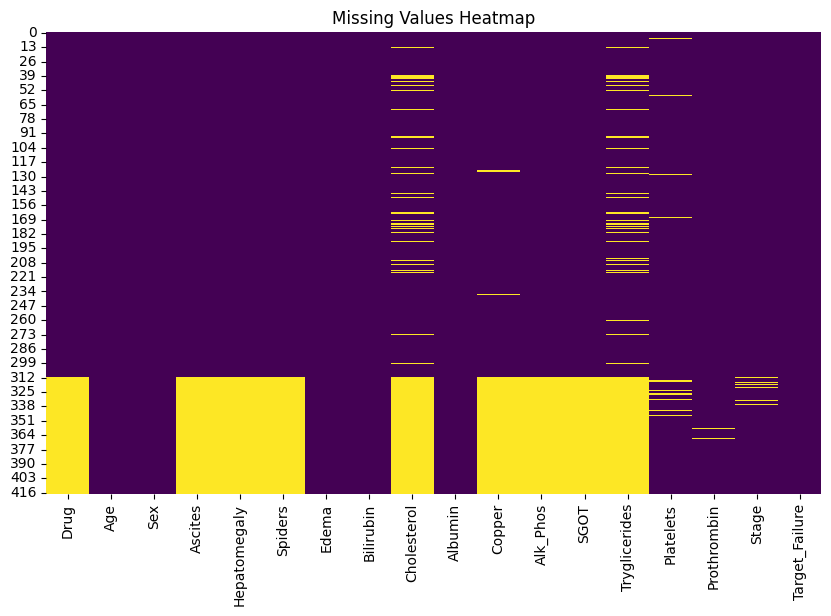

In [12]:
missing_perc = df.isnull().mean() * 100
print(missing_perc[missing_perc > 0].sort_values(ascending=False))  # e.g., Triglycerides: 32.3%

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

##### Drop missing values and impute
- Drop missing values if Drug,Ascites,Hepatomegaly,Spiders,Cholesterol,Copper,Alk_Phos,Tryglicerides missing
- Impute other missing values using KNN Imputer

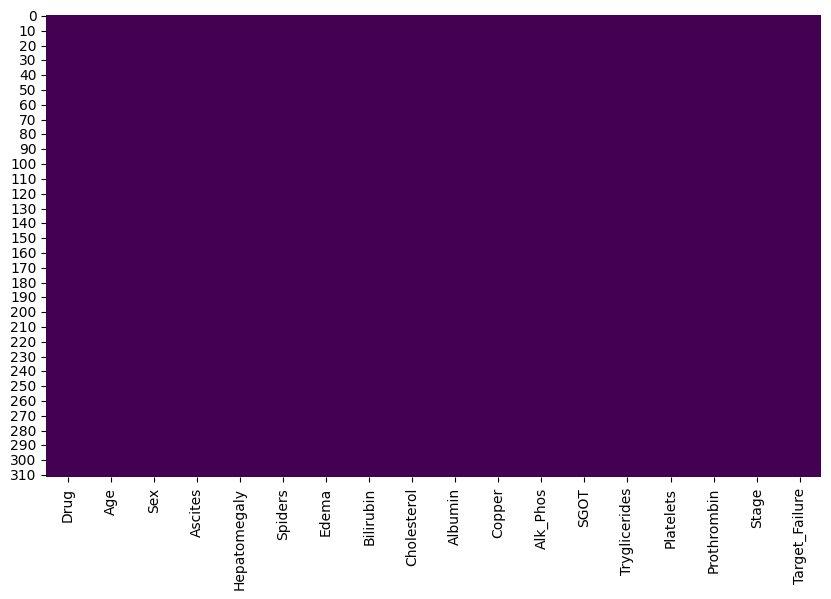

In [13]:
# 1. Clean the categorical starting point
df = df.dropna(subset=['Drug'])

# 2. Define features and initialize tools
num_features = ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
                'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

scaler = StandardScaler()
imputer = KNNImputer(n_neighbors=5)

# 3. STEP-BY-STEP: Scale -> Impute -> Unscale (to keep original units)
# We scale first so KNN distance is fair
scaled_data = scaler.fit_transform(df[num_features])

# Now we fill the holes based on the scaled 'fair' distances
imputed_data = imputer.fit_transform(scaled_data)

# We convert back to original units so 'Age' isn't a small decimal anymore
df[num_features] = scaler.inverse_transform(imputed_data)

# 4. Verify with your Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [14]:
df.head()

,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Target_Failure
0,D-penicillamine,21464.0,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,1
1,D-penicillamine,20617.0,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,0
2,D-penicillamine,25594.0,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,1
3,D-penicillamine,19994.0,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,1
4,Placebo,13918.0,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,1


In [15]:
from sklearn.model_selection import train_test_split

df , df_test = train_test_split(df, test_size=0.2, random_state=42)

print(f"Train dataset : {df.shape}")
print(f"Train dataset : {df_test.shape}")

Train dataset : (249, 18)
Train dataset : (63, 18)


#### Clustering

Categorical Columns: Index(['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Stage'], dtype='object')
Categorical Indices: [0, 2, 3, 4, 5, 6, 16]


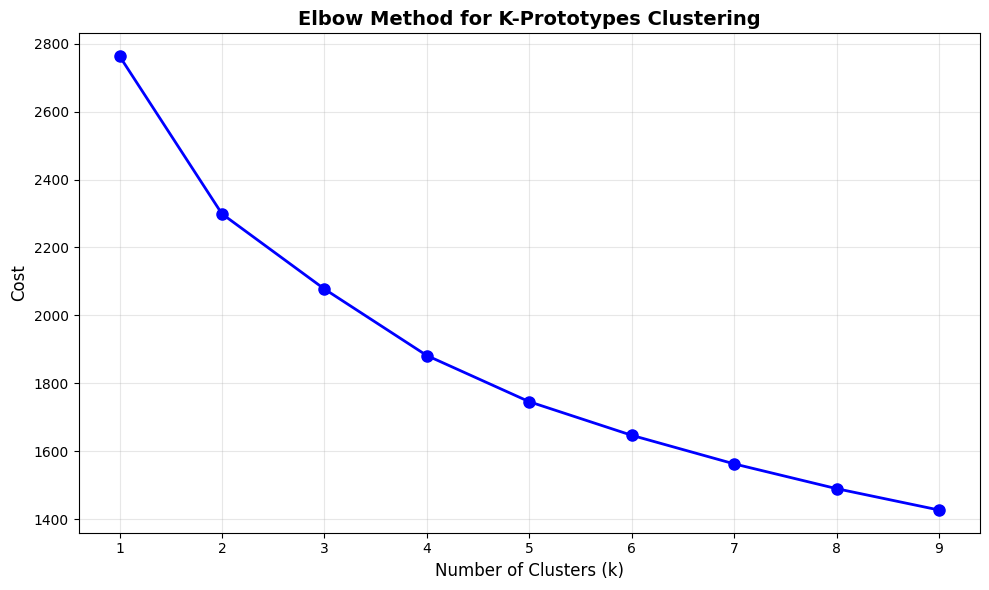

K range tested: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Costs: [np.float64(2763.9999999999986), np.float64(2299.1137260969244), np.float64(2077.7059264640784), np.float64(1881.6930539042626), np.float64(1745.6035282957741), np.float64(1646.7379792890742), np.float64(1562.5082997093684), np.float64(1489.5050573193855), np.float64(1426.553592707981)]


In [16]:
# Prepare data for K-Prototypes clustering
X = df.drop(columns=['Target_Failure'])  # Drop the binary target, we want to cluster on the original features

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

# Scale numerical features
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
X[num_cols] = X[num_cols].astype(float)

# Convert categorical columns to string
for col in cat_cols:
    X[col] = X[col].astype(str)

# Convert to numpy
X_matrix = np.array(X.values, dtype=object)

# Get categorical column indices
cat_indices = [X.columns.get_loc(col) for col in cat_cols]

print("Categorical Columns:", cat_cols)
print("Categorical Indices:", cat_indices)

# Elbow Method for K-Prototypes clustering
costs = []
K_range = range(1, 10)

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Huang', random_state=42, verbose=0)
    clusters = kproto.fit_predict(X_matrix, categorical=cat_indices)
    costs.append(kproto.cost_)

# Visualize the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(K_range, costs, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Cost", fontsize=12)
plt.title("Elbow Method for K-Prototypes Clustering", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print(f"K range tested: {list(K_range)}")
print(f"Costs: {costs}")

In [17]:
# Fit Final Model
optimal_k = 2

kproto = KPrototypes(n_clusters=optimal_k, init='Huang', random_state=42)
clusters = kproto.fit_predict(X_matrix, categorical=cat_indices)

df["Cluster"] = clusters

In [18]:
df.head()

,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Target_Failure,Cluster
111,Placebo,20256.0,F,N,Y,Y,N,2.0,267.0,3.67,89.0,754.0,196.85,90.0,136.0,11.8,4.0,1,0
208,Placebo,19221.0,F,N,Y,Y,N,0.7,252.0,4.01,11.0,1210.0,72.85,58.0,309.0,9.5,2.0,0,0
145,Placebo,12369.0,F,N,N,N,S,1.2,361.0,3.89,58.0,1284.0,173.60,110.4,239.0,9.4,3.0,0,0
203,Placebo,22857.0,F,N,N,N,N,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,281.0,10.2,3.0,1,0
78,D-penicillamine,16990.0,F,N,Y,N,N,0.8,315.0,4.24,13.0,1637.0,170.50,70.0,426.0,10.9,3.0,0,0


In [19]:
# Clusters and Target Failure	comparison
pd.crosstab(df['Cluster'], df['Target_Failure'])

Target_Failure,0,1
Cluster,,
0,129,58
1,10,52


In [20]:
df.head()

,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Target_Failure,Cluster
111,Placebo,20256.0,F,N,Y,Y,N,2.0,267.0,3.67,89.0,754.0,196.85,90.0,136.0,11.8,4.0,1,0
208,Placebo,19221.0,F,N,Y,Y,N,0.7,252.0,4.01,11.0,1210.0,72.85,58.0,309.0,9.5,2.0,0,0
145,Placebo,12369.0,F,N,N,N,S,1.2,361.0,3.89,58.0,1284.0,173.60,110.4,239.0,9.4,3.0,0,0
203,Placebo,22857.0,F,N,N,N,N,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,281.0,10.2,3.0,1,0
78,D-penicillamine,16990.0,F,N,Y,N,N,0.8,315.0,4.24,13.0,1637.0,170.50,70.0,426.0,10.9,3.0,0,0


In [21]:
# Split training data
X_train = df.drop(columns=['Target_Failure'])
y_train = df['Target_Failure']

# Split test data
X_test = df_test.drop(columns=['Target_Failure'])
y_test = df_test['Target_Failure']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (249, 18)
y_train shape: (249,)
X_test shape: (63, 17)
y_test shape: (63,)


In [22]:
X_train.head()

,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Cluster
111,Placebo,20256.0,F,N,Y,Y,N,2.0,267.0,3.67,89.0,754.0,196.85,90.0,136.0,11.8,4.0,0
208,Placebo,19221.0,F,N,Y,Y,N,0.7,252.0,4.01,11.0,1210.0,72.85,58.0,309.0,9.5,2.0,0
145,Placebo,12369.0,F,N,N,N,S,1.2,361.0,3.89,58.0,1284.0,173.60,110.4,239.0,9.4,3.0,0
203,Placebo,22857.0,F,N,N,N,N,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,281.0,10.2,3.0,0
78,D-penicillamine,16990.0,F,N,Y,N,N,0.8,315.0,4.24,13.0,1637.0,170.50,70.0,426.0,10.9,3.0,0


## Logistic Regression Model

In [23]:
# Perform one-hot encoding on categorical features in X_train
X_train_ohe = pd.get_dummies(X_train, columns=X_train.select_dtypes(include=['object', 'category']).columns, drop_first=True)

print("One-hot encoding complete!")
print(f"New shape: {X_train_ohe.shape}")
X_train_ohe.head()

One-hot encoding complete!
New shape: (249, 21)


,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,...,Drug_Placebo,Sex_M,Ascites_Y,Hepatomegaly_Y,Spiders_Y,Edema_S,Edema_Y,Stage_2.0,Stage_3.0,Stage_4.0
111,20256.0,2.0,267.0,3.67,89.0,754.0,196.85,90.0,136.0,11.8,...,True,False,False,True,True,False,False,False,False,True
208,19221.0,0.7,252.0,4.01,11.0,1210.0,72.85,58.0,309.0,9.5,...,True,False,False,True,True,False,False,True,False,False
145,12369.0,1.2,361.0,3.89,58.0,1284.0,173.60,110.4,239.0,9.4,...,True,False,False,False,False,True,False,False,True,False
203,22857.0,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,281.0,10.2,...,True,False,False,False,False,False,False,False,True,False
78,16990.0,0.8,315.0,4.24,13.0,1637.0,170.50,70.0,426.0,10.9,...,False,False,False,True,False,False,False,False,True,False


In [24]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns in the one-hot encoded training set
num_features_ohe = X_train_ohe.select_dtypes(include=['int64', 'float64']).columns

# Initialize and fit the scaler
scaler_fin = StandardScaler()

# Create X_train_fin as a copy and scale the numerical features
X_train_fin = X_train_ohe.copy()
X_train_fin[num_features_ohe] = scaler_fin.fit_transform(X_train_ohe[num_features_ohe])

print("X_train_fin created and scaled successfully!")
print(f"Final shape: {X_train_fin.shape}")
X_train_fin.head()

X_train_fin created and scaled successfully!
Final shape: (249, 21)


,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,...,Drug_Placebo,Sex_M,Ascites_Y,Hepatomegaly_Y,Spiders_Y,Edema_S,Edema_Y,Stage_2.0,Stage_3.0,Stage_4.0
111,0.540641,-0.257737,-0.460450,0.324999,-0.102065,-0.568233,1.377738,-0.529995,-1.317085,1.03258,...,True,False,False,True,True,False,False,False,False,True
208,0.275333,-0.543258,-0.527123,1.121133,-1.028726,-0.363499,-0.887995,-1.024688,0.481662,-1.21337,...,True,False,False,True,True,False,False,True,False,False
145,-1.481084,-0.433442,-0.042632,0.840145,-0.470354,-0.330274,0.952913,-0.214628,-0.246155,-1.31102,...,True,False,False,False,False,True,False,False,True,False
203,1.207372,-0.543258,-0.513788,0.488909,-0.886163,-0.447009,-0.803030,-1.024688,0.190535,-0.52982,...,True,False,False,False,False,False,False,False,True,False
78,-0.296553,-0.521295,-0.247096,1.659695,-1.004966,-0.171785,0.896270,-0.839178,1.698155,0.15373,...,False,False,False,True,False,False,False,False,True,False


In [26]:
# Initialize and fit the model
from sklearn.linear_model import LogisticRegression
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model.fit(X_train_fin, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [27]:
# Remove Cluster column from X_train_fin
X_train_clusterless = X_train_fin.drop(columns=['Cluster'], errors='ignore')

# Initialize and fit the clusterless model
from sklearn.linear_model import LogisticRegression
log_reg_model_clusterless = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model_clusterless.fit(X_train_clusterless, y_train)

print("Model 'log_reg_model_clusterless' trained successfully.")
print(f"New shape: {X_train_clusterless.shape}")

Model 'log_reg_model_clusterless' trained successfully.
New shape: (249, 20)


### Evaluating with test data

In [32]:
#Testing with test data
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predictions on the scaled training data
y_train_pred1 = log_reg_model_clusterless.predict(X_train_clusterless)

# Calculate evaluation metrics
accuracy = accuracy_score(y_train, y_train_pred1)
precision = precision_score(y_train, y_train_pred1, average='weighted')
recall = recall_score(y_train, y_train_pred1, average='weighted')
f1 = f1_score(y_train, y_train_pred1, average='weighted')

print("="*65)
print("LOGISTIC REGRESSION EVALUATION (X_train_fin) - Without Clusters")
print("="*65)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_train_pred1))

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred1))

LOGISTIC REGRESSION EVALUATION (X_train_fin) - Without Clusters
Accuracy:  0.8434
Precision: 0.8439
Recall:    0.8434
F1-Score:  0.8425

Confusion Matrix:
[[124  15]
 [ 24  86]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       139
           1       0.85      0.78      0.82       110

    accuracy                           0.84       249
   macro avg       0.84      0.84      0.84       249
weighted avg       0.84      0.84      0.84       249



In [35]:
#Testing with test data
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predictions on the scaled training data
y_train_pred = log_reg_model.predict(X_train_fin)

# Calculate evaluation metrics
accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred, average='weighted')
recall = recall_score(y_train, y_train_pred, average='weighted')
f1 = f1_score(y_train, y_train_pred, average='weighted')

print("="*90)
print("LOGISTIC REGRESSION EVALUATION (X_train_fin) - With clusters")
print("="*90)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

LOGISTIC REGRESSION EVALUATION (X_train_fin) - With clusters
Accuracy:  0.8514
Precision: 0.8515
Recall:    0.8514
F1-Score:  0.8508

Confusion Matrix:
[[124  15]
 [ 22  88]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       139
           1       0.85      0.80      0.83       110

    accuracy                           0.85       249
   macro avg       0.85      0.85      0.85       249
weighted avg       0.85      0.85      0.85       249



In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Using the training predictions already generated in cells DPMaI9q55OCj and rlLuABCt6vEk
# y_train_pred = model WITH clusters
# y_train_pred1 = model WITHOUT clusters

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Results for Model with Clusters
results_with = [
    accuracy_score(y_train, y_train_pred),
    precision_score(y_train, y_train_pred, average='weighted'),
    recall_score(y_train, y_train_pred, average='weighted'),
    f1_score(y_train, y_train_pred, average='weighted')
]

# Results for Model without Clusters
results_no = [
    accuracy_score(y_train, y_train_pred1),
    precision_score(y_train, y_train_pred1, average='weighted'),
    recall_score(y_train, y_train_pred1, average='weighted'),
    f1_score(y_train, y_train_pred1, average='weighted')
]

# Display Comparison Table
print("="*80)
print(f"{'Metric':<15} | {'With Clusters':<15} | {'Without Clusters':<18} | {'Diff'}")
print("-"*80)
for i in range(len(metrics)):
    diff = results_with[i] - results_no[i]
    print(f"{metrics[i]:<15} | {results_with[i]:.4f}{'':<10} | {results_no[i]:.4f}{'':<13} | {diff:+.4f}")
print("="*80)

# Summary
print(f"\nSummary: Adding clusters to the Logistic Regression improved training accuracy by {results_with[0] - results_no[0]:.2%}.")

Metric          | With Clusters   | Without Clusters   | Diff
--------------------------------------------------------------------------------
Accuracy        | 0.8514           | 0.8434              | +0.0080
Precision       | 0.8515           | 0.8439              | +0.0077
Recall          | 0.8514           | 0.8434              | +0.0080
F1-Score        | 0.8508           | 0.8425              | +0.0083

Summary: Adding clusters to the Logistic Regression improved training accuracy by 0.80%.


### Evaluating with Test Data

In [39]:
# 1. Apply One-Hot Encoding to X_test
X_test_ohe = pd.get_dummies(X_test, columns=X_test.select_dtypes(include=['object', 'category']).columns, drop_first=True)

# 2. Align columns with X_train_ohe (ensure same features and order)
# Add missing columns with 0s and remove extra ones
for col in set(X_train_ohe.columns) - set(X_test_ohe.columns):
    X_test_ohe[col] = 0

# Drop columns that were in test but not in train, and reorder to match exactly
X_test_ohe = X_test_ohe[X_train_ohe.columns.drop('Cluster', errors='ignore')]

# 3. Scale numerical features using the fitted scaler_fin
X_test_fin = X_test_ohe.copy()
X_test_fin[num_features_ohe] = scaler_fin.transform(X_test_ohe[num_features_ohe])

print("X_test_fin created and scaled successfully!")
print(f"Test feature count: {X_test_fin.shape[1]}")
X_test_fin.head()

X_test_fin created and scaled successfully!
Test feature count: 20


,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Drug_Placebo,Sex_M,Ascites_Y,Hepatomegaly_Y,Spiders_Y,Edema_S,Edema_Y,Stage_2.0,Stage_3.0,Stage_4.0
228,1.191992,0.291343,-0.798260,-1.126776,1.216644,-0.448804,0.981235,-0.097138,-1.285893,0.641980,False,False,True,True,False,True,False,False,False,True
9,1.954593,2.070362,-0.758256,-1.852663,0.503828,-0.494600,0.471445,0.289341,0.408880,0.739630,True,False,True,False,True,False,True,False,False,True
57,-0.478809,-0.543258,-0.571571,1.285043,-0.292150,1.737722,-1.181992,-0.097138,-0.007015,-0.139220,False,True,False,False,False,False,False,False,False,False
60,-0.541611,-0.565221,-0.687138,0.957223,-0.826762,-0.636927,-1.114568,0.985003,-0.537282,2.204381,True,True,False,False,False,False,False,False,False,False
25,0.219195,0.445085,3.366586,0.348415,-0.529755,0.542540,0.811305,0.644902,1.646168,-0.822770,True,False,False,True,True,False,False,False,True,False


In [40]:
# Remove Cluster column from X_test_fin
X_test_clusterless = X_test_fin.drop(columns=['Cluster'], errors='ignore')

# Initialize and fit the clusterless model
from sklearn.linear_model import LogisticRegression
log_reg_model_clusterless2 = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model_clusterless2.fit(X_test_clusterless, y_test)

print("Model 'log_reg_model_clusterless' trained successfully.")
print(f"New shape: {X_test_clusterless.shape}")

Model 'log_reg_model_clusterless' trained successfully.
New shape: (63, 20)


In [41]:
#Testing with test data - Clusterless
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predictions on the scaled training data
y_test_pred1 = log_reg_model_clusterless2.predict(X_test_clusterless)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_test_pred1)
precision = precision_score(y_test, y_test_pred1, average='weighted')
recall = recall_score(y_test, y_test_pred1, average='weighted')
f1 = f1_score(y_test, y_test_pred1, average='weighted')

print("="*65)
print("LOGISTIC REGRESSION EVALUATION (X_test_fin) - Without Clusters")
print("="*65)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred1))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred1))

LOGISTIC REGRESSION EVALUATION (X_test_fin) - Without Clusters
Accuracy:  0.8095
Precision: 0.8117
Recall:    0.8095
F1-Score:  0.8098

Confusion Matrix:
[[24  5]
 [ 7 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        29
           1       0.84      0.79      0.82        34

    accuracy                           0.81        63
   macro avg       0.81      0.81      0.81        63
weighted avg       0.81      0.81      0.81        63



In [42]:
# Initialize and fit the model
log_reg_model3 = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model3.fit(X_test_fin, y_test)

LogisticRegression(max_iter=1000, random_state=42)

In [43]:
#Testing with test data
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predictions on the scaled training data
y_test_pred3 = log_reg_model3.predict(X_test_fin)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_test_pred3)
precision = precision_score(y_test, y_test_pred3, average='weighted')
recall = recall_score(y_test, y_test_pred3, average='weighted')
f1 = f1_score(y_test, y_test_pred3, average='weighted')

print("="*50)
print("LOGISTIC REGRESSION EVALUATION (X_test_fin)")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred3))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred3))

LOGISTIC REGRESSION EVALUATION (X_test_fin)
Accuracy:  0.8095
Precision: 0.8117
Recall:    0.8095
F1-Score:  0.8098

Confusion Matrix:
[[24  5]
 [ 7 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        29
           1       0.84      0.79      0.82        34

    accuracy                           0.81        63
   macro avg       0.81      0.81      0.81        63
weighted avg       0.81      0.81      0.81        63



In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Predictions for the final test models
# Model with clusters (using the test data aligned for that model)
y_pred_test_with = log_reg_model3.predict(X_test_fin)

# Model without clusters (using the test data aligned for that model)
y_pred_test_no = log_reg_model_clusterless2.predict(X_test_clusterless)

# 2. Define metrics for comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

results_with = [
    accuracy_score(y_test, y_pred_test_with),
    precision_score(y_test, y_pred_test_with, average='weighted'),
    recall_score(y_test, y_pred_test_with, average='weighted'),
    f1_score(y_test, y_pred_test_with, average='weighted')
]

results_no = [
    accuracy_score(y_test, y_pred_test_no),
    precision_score(y_test, y_pred_test_no, average='weighted'),
    recall_score(y_test, y_pred_test_no, average='weighted'),
    f1_score(y_test, y_pred_test_no, average='weighted')
]

# 3. Print the comparison table
print("="*80)
print(f"{'Metric':<15} | {'With Clusters':<15} | {'Without Clusters':<18} | {'Diff'}")
print("-"*80)
for i in range(len(metrics)):
    diff = results_with[i] - results_no[i]
    print(f"{metrics[i]:<15} | {results_with[i]:.4f}{'':<10} | {results_no[i]:.4f}{'':<13} | {diff:+.4f}")
print("="*80)

# Quick Summary
print(f"\nSummary: The model with clusters shows a {results_with[0] - results_no[0]:.2%} improvement in accuracy on the test set.")

Metric          | With Clusters   | Without Clusters   | Diff
--------------------------------------------------------------------------------
Accuracy        | 0.8095           | 0.8095              | +0.0000
Precision       | 0.8117           | 0.8117              | +0.0000
Recall          | 0.8095           | 0.8095              | +0.0000
F1-Score        | 0.8098           | 0.8098              | +0.0000

Summary: The model with clusters shows a 0.00% improvement in accuracy on the test set.


## Decision Tree Model

Evaluating Training Data

In [52]:
X_train_ohe

,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,...,Drug_Placebo,Sex_M,Ascites_Y,Hepatomegaly_Y,Spiders_Y,Edema_S,Edema_Y,Stage_2.0,Stage_3.0,Stage_4.0
111,20256.0,2.0,267.0,3.67,89.0,754.0,196.85,90.0,136.0,11.8,...,True,False,False,True,True,False,False,False,False,True
208,19221.0,0.7,252.0,4.01,11.0,1210.0,72.85,58.0,309.0,9.5,...,True,False,False,True,True,False,False,True,False,False
145,12369.0,1.2,361.0,3.89,58.0,1284.0,173.60,110.4,239.0,9.4,...,True,False,False,False,False,True,False,False,True,False
203,22857.0,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,281.0,10.2,...,True,False,False,False,False,False,False,False,True,False
78,16990.0,0.8,315.0,4.24,13.0,1637.0,170.50,70.0,426.0,10.9,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,18499.0,1.3,360.0,3.63,52.0,1812.0,97.65,164.0,256.0,9.9,...,True,False,False,True,False,False,False,False,True,False
71,11868.0,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,...,True,False,False,False,False,False,False,False,True,False
106,22836.0,0.6,212.0,4.03,10.0,648.0,71.30,77.0,316.0,17.1,...,True,False,False,False,False,False,False,False,False,False
270,18435.0,1.0,321.0,3.50,94.0,955.0,111.00,177.0,289.0,9.7,...,True,False,False,True,False,False,False,False,True,False


In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize the Decision Tree with the requested pruning parameters
# max_depth=5 and min_samples_leaf=10 help prevent overfitting on this clinical dataset
dt_clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

# 2. Fit the model using the prepared OHE training data
# We ensure we drop the 'Cluster' column if it was added to X_train_ohe previously to match the user's specific request for the OHE set
X_train_dt = X_train_ohe.drop(columns=['Cluster'], errors='ignore')
dt_clf.fit(X_train_dt, y_train)

# 3. Evaluate the model on the training set
y_train_pred_dt = dt_clf.predict(X_train_dt)

print("="*60)
print("DECISION TREE TRAINING RESULTS (max_depth=5, min_samples_leaf=10)")
print("="*60)
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_dt):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_train_pred_dt))

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred_dt))

# 4. Feature Importance
importances = pd.Series(dt_clf.feature_importances_, index=X_train_dt.columns)
print("\nTop 5 Most Important Features:")
print(importances.sort_values(ascending=False).head(5))

DECISION TREE TRAINING RESULTS (max_depth=5, min_samples_leaf=10)
Training Accuracy: 0.8313

Confusion Matrix:
[[122  17]
 [ 25  85]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       139
           1       0.83      0.77      0.80       110

    accuracy                           0.83       249
   macro avg       0.83      0.83      0.83       249
weighted avg       0.83      0.83      0.83       249


Top 5 Most Important Features:
Bilirubin      0.558945
Sex_M          0.101163
Copper         0.098990
Prothrombin    0.053478
Alk_Phos       0.052802
dtype: float64


In [47]:
from sklearn.tree import DecisionTreeClassifier

# 1. Prepare the training data (ensure Cluster is present)
X_train_dt_clustered = X_train_ohe.copy()
if 'Cluster' not in X_train_dt_clustered.columns:
    X_train_dt_clustered['Cluster'] = df['Cluster']

# 2. Initialize and Fit the Decision Tree
dt_clf_clustered = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

dt_clf_clustered.fit(X_train_dt_clustered, y_train)

print("Model 'dt_clf_clustered' fitted successfully using features:", X_train_dt_clustered.columns.tolist())

Model 'dt_clf_clustered' fitted successfully using features: ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Cluster', 'Drug_Placebo', 'Sex_M', 'Ascites_Y', 'Hepatomegaly_Y', 'Spiders_Y', 'Edema_S', 'Edema_Y', 'Stage_2.0', 'Stage_3.0', 'Stage_4.0']


In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Ensure X_train_dt_clustered is ready (with the Cluster feature)
X_train_dt_clustered = X_train_ohe.copy()
if 'Cluster' not in X_train_dt_clustered.columns:
    X_train_dt_clustered['Cluster'] = df['Cluster']

# 2. Predict on the training set
y_train_pred_dtc = dt_clf_clustered.predict(X_train_dt_clustered)

# 3. Evaluate results
print("="*65)
print("CLUSTERED DECISION TREE - TRAINING DATA EVALUATION")
print("="*65)
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_dtc):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_train_pred_dtc))
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred_dtc))

CLUSTERED DECISION TREE - TRAINING DATA EVALUATION
Training Accuracy: 0.8313

Confusion Matrix:
[[122  17]
 [ 25  85]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       139
           1       0.83      0.77      0.80       110

    accuracy                           0.83       249
   macro avg       0.83      0.83      0.83       249
weighted avg       0.83      0.83      0.83       249



In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Calculate metrics for Unclustered Model (dt_clf)
# y_train_pred_dt was generated in cell a0F-29YozLq-
dt_metrics_no = [
    accuracy_score(y_train, y_train_pred_dt),
    precision_score(y_train, y_train_pred_dt, average='weighted'),
    recall_score(y_train, y_train_pred_dt, average='weighted'),
    f1_score(y_train, y_train_pred_dt, average='weighted')
]

# Calculate metrics for Clustered Model (dt_clf_clustered)
# y_train_pred_dtc was generated in cell eHE8SxWE2wbz
dt_metrics_with = [
    accuracy_score(y_train, y_train_pred_dtc),
    precision_score(y_train, y_train_pred_dtc, average='weighted'),
    recall_score(y_train, y_train_pred_dtc, average='weighted'),
    f1_score(y_train, y_train_pred_dtc, average='weighted')
]

# Create comparison table
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
comparison_df = pd.DataFrame({
    'Metric': metrics_labels,
    'dt_clf (No Cluster)': dt_metrics_no,
    'dt_clf_clustered': dt_metrics_with
})

print("="*60)
print("DECISION TREE MODELS COMPARISON (TRAINING DATA)")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

diff = dt_metrics_with[0] - dt_metrics_no[0]
print(f"\nObservation: The training accuracy difference is {diff:.4f}.")

DECISION TREE MODELS COMPARISON (TRAINING DATA)
   Metric  dt_clf (No Cluster)  dt_clf_clustered
 Accuracy             0.831325          0.831325
Precision             0.831435          0.831435
   Recall             0.831325          0.831325
 F1-Score             0.830502          0.830502

Observation: The training accuracy difference is 0.0000.


In [51]:
import pandas as pd

# 1. Apply One-Hot Encoding to X_test
X_test_ohe_reformed = pd.get_dummies(X_test, columns=X_test.select_dtypes(include=['object', 'category']).columns, drop_first=True)

# 2. Align columns with X_train_ohe
# We ensure all columns present in the training set are present here
for col in X_train_ohe.columns:
    if col not in X_test_ohe_reformed.columns and col != 'Cluster':
        X_test_ohe_reformed[col] = 0

# 3. Ensure the order of columns matches X_train_ohe (excluding Cluster if it wasn't intended for this specific set)
train_cols = [c for c in X_train_ohe.columns if c != 'Cluster']
X_test_ohe_reformed = X_test_ohe_reformed[train_cols]

print(f"Original X_test shape: {X_test.shape}")
print(f"Transformed X_test_ohe shape: {X_test_ohe_reformed.shape}")
X_test_ohe_reformed.head()

Original X_test shape: (63, 17)
Transformed X_test_ohe shape: (63, 20)


,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Drug_Placebo,Sex_M,Ascites_Y,Hepatomegaly_Y,Spiders_Y,Edema_S,Edema_Y,Stage_2.0,Stage_3.0,Stage_4.0
228,22797.0,4.5,191.0,3.05,200.0,1020.0,175.15,118.0,139.0,11.4,False,False,True,True,False,True,False,False,False,True
9,25772.0,12.6,200.0,2.74,140.0,918.0,147.25,143.0,302.0,11.5,True,False,True,False,True,False,True,False,False,True
57,16279.0,0.7,242.0,4.08,73.0,5890.0,56.76,118.0,262.0,10.6,False,True,False,False,False,False,False,False,False,False
60,16034.0,0.6,216.0,3.94,28.0,601.0,60.45,188.0,211.0,13.0,True,True,False,False,False,False,False,False,False,False
25,19002.0,5.2,1128.0,3.68,53.0,3228.0,165.85,166.0,421.0,9.9,True,False,False,True,True,False,False,False,True,False


In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Predict using the unclustered Decision Tree model (dt_clf)
# This model was trained on X_train_dt (which excludes the Cluster feature)
y_test_pred_dt = dt_clf.predict(X_test_ohe_reformed)

# 2. Evaluate performance metrics on the test set
print("="*60)
print("UNCLUSTERED DECISION TREE - TEST DATA EVALUATION")
print("="*60)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_dt):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_dt))

UNCLUSTERED DECISION TREE - TEST DATA EVALUATION
Test Accuracy: 0.6190

Confusion Matrix:
[[20  9]
 [15 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.69      0.62        29
           1       0.68      0.56      0.61        34

    accuracy                           0.62        63
   macro avg       0.62      0.62      0.62        63
weighted avg       0.63      0.62      0.62        63



In [56]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Prepare X_test for K-Prototypes (scaling and type conversion to match training)
X_test_proto = X_test.copy()
num_cols_proto = X_test_proto.select_dtypes(include=['int64', 'float64']).columns
cat_cols_proto = X_test_proto.select_dtypes(include=['object', 'category']).columns

# Use the scaler from the training clustering step
X_test_proto[num_cols_proto] = scaler.transform(X_test_proto[num_cols_proto])
for col in cat_cols_proto:
    X_test_proto[col] = X_test_proto[col].astype(str)

X_test_matrix = np.array(X_test_proto.values, dtype=object)

# 2. Predict Clusters for the Test Set
test_clusters = kproto.predict(X_test_matrix, categorical=cat_indices)

# 3. Add the Cluster column and ensure EXACT column order as seen in X_train_dt_clustered
X_test_dt_clustered = X_test_ohe_reformed.copy()
X_test_dt_clustered['Cluster'] = test_clusters

# Reorder columns to match the training set exactly
X_test_dt_clustered = X_test_dt_clustered[X_train_dt_clustered.columns]

# 4. Predict using the clustered Decision Tree
y_test_pred_dtc = dt_clf_clustered.predict(X_test_dt_clustered)

# 5. Evaluate Results
print("="*65)
print("CLUSTERED DECISION TREE - TEST DATA EVALUATION")
print("="*65)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_dtc):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_dtc))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_dtc))

CLUSTERED DECISION TREE - TEST DATA EVALUATION
Test Accuracy: 0.6190

Confusion Matrix:
[[20  9]
 [15 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.69      0.62        29
           1       0.68      0.56      0.61        34

    accuracy                           0.62        63
   macro avg       0.62      0.62      0.62        63
weighted avg       0.63      0.62      0.62        63



In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# 1. Prepare data (ensure Cluster is removed)
X_train_rf = X_train_ohe.drop(columns=['Cluster'], errors='ignore')
X_test_rf = X_test_ohe_reformed.copy()

# 2. Define the parameter grid based on your requirements
param_grid = {
    'n_estimators': [200],
    'max_depth': [5, 6, 7],
    'min_samples_split': [15, 20],
    'min_samples_leaf': [8, 10],
    'max_features': ['sqrt'],
    'class_weight': ['balanced'],
    'random_state': [42]
}

# 3. Initialize and fit GridSearchCV
rf_base = RandomForestClassifier()
grid_search_rf = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search_rf.fit(X_train_rf, y_train)

# 4. Get the best model
best_rf_model = grid_search_rf.best_estimator_
print(f"Best Parameters: {grid_search_rf.best_params_}")

Best Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 15, 'n_estimators': 200, 'random_state': 42}


In [58]:
# 5. Predictions
y_test_pred_rf = best_rf_model.predict(X_test_rf)

# 6. Evaluation Metrics
print("="*60)
print("RANDOM FOREST (UNCLUSTERED) - TEST DATA EVALUATION")
print("="*60)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"Test F1-Score (Weighted): {f1_score(y_test, y_test_pred_rf, average='weighted'):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf))

# 7. Feature Importance
rf_importances = pd.Series(best_rf_model.feature_importances_, index=X_train_rf.columns)
print("\nTop 5 Most Important Features (RF):")
print(rf_importances.sort_values(ascending=False).head(5))

RANDOM FOREST (UNCLUSTERED) - TEST DATA EVALUATION
Test Accuracy: 0.7460
Test F1-Score (Weighted): 0.7464

Confusion Matrix:
[[22  7]
 [ 9 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.76      0.73        29
           1       0.78      0.74      0.76        34

    accuracy                           0.75        63
   macro avg       0.75      0.75      0.75        63
weighted avg       0.75      0.75      0.75        63


Top 5 Most Important Features (RF):
Bilirubin      0.238306
Copper         0.172445
Prothrombin    0.124575
Albumin        0.082161
SGOT           0.078170
dtype: float64


In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# 1. Prepare data (including the Cluster feature)
X_train_rf_c = X_train_ohe.copy()
if 'Cluster' not in X_train_rf_c.columns:
    X_train_rf_c['Cluster'] = df['Cluster']

X_test_rf_c = X_test_ohe_reformed.copy()
X_test_rf_c['Cluster'] = test_clusters

# Reorder columns to ensure exact match
X_test_rf_c = X_test_rf_c[X_train_rf_c.columns]

# 2. Define the parameter grid (same as before)
param_grid = {
    'n_estimators': [200],
    'max_depth': [5, 6, 7],
    'min_samples_split': [15, 20],
    'min_samples_leaf': [8, 10],
    'max_features': ['sqrt'],
    'class_weight': ['balanced'],
    'random_state': [42]
}

# 3. Fit GridSearchCV
rf_clustered_base = RandomForestClassifier()
grid_search_rf_c = GridSearchCV(estimator=rf_clustered_base, param_grid=param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search_rf_c.fit(X_train_rf_c, y_train)

# 4. Best model and evaluation
best_rf_c_model = grid_search_rf_c.best_estimator_
y_test_pred_rf_c = best_rf_c_model.predict(X_test_rf_c)

print("="*60)
print("RANDOM FOREST (WITH CLUSTERS) - TEST DATA EVALUATION")
print("="*60)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_rf_c):.4f}")
print(f"Test F1-Score (Weighted): {f1_score(y_test, y_test_pred_rf_c, average='weighted'):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_rf_c))

# 5. Feature Importance
rf_c_importances = pd.Series(best_rf_c_model.feature_importances_, index=X_train_rf_c.columns)
print("\nTop 5 Most Important Features (Clustered RF):")
print(rf_c_importances.sort_values(ascending=False).head(5))

RANDOM FOREST (WITH CLUSTERS) - TEST DATA EVALUATION
Test Accuracy: 0.7460
Test F1-Score (Weighted): 0.7464

Confusion Matrix:
[[22  7]
 [ 9 25]]

Top 5 Most Important Features (Clustered RF):
Bilirubin      0.228248
Copper         0.168221
Prothrombin    0.132286
SGOT           0.086915
Cluster        0.067840
dtype: float64


In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Metrics for Unclustered RF
rf_metrics_no = [
    accuracy_score(y_test, y_test_pred_rf),
    precision_score(y_test, y_test_pred_rf, average='weighted'),
    recall_score(y_test, y_test_pred_rf, average='weighted'),
    f1_score(y_test, y_test_pred_rf, average='weighted')
]

# Metrics for Clustered RF
rf_metrics_with = [
    accuracy_score(y_test, y_test_pred_rf_c),
    precision_score(y_test, y_test_pred_rf_c, average='weighted'),
    recall_score(y_test, y_test_pred_rf_c, average='weighted'),
    f1_score(y_test, y_test_pred_rf_c, average='weighted')
]

# Create comparison table
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
comparison_rf_df = pd.DataFrame({
    'Metric': labels,
    'RF (No Clusters)': rf_metrics_no,
    'RF (With Clusters)': rf_metrics_with
})

print("="*60)
print("RANDOM FOREST MODELS COMPARISON (TEST DATA)")
print("="*60)
display(comparison_rf_df)
print("="*60)

# Final Summary
print(f"\nSummary: Both Random Forest models achieved a test accuracy of {rf_metrics_no[0]:.2%}.")
print("While performance is identical, the clustered model utilizes the 'Cluster' feature as the 5th most important predictor.")

RANDOM FOREST MODELS COMPARISON (TEST DATA)


,Metric,RF (No Clusters),RF (With Clusters)
0,Accuracy,0.746032,0.746032
1,Precision,0.748304,0.748304
2,Recall,0.746032,0.746032
3,F1-Score,0.746417,0.746417



Summary: Both Random Forest models achieved a test accuracy of 74.60%.
While performance is identical, the clustered model utilizes the 'Cluster' feature as the 5th most important predictor.


In [63]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# 1. Prepare data (Ensuring Cluster is removed for unclustered baseline)
X_train_xgb = X_train_ohe.drop(columns=['Cluster'], errors='ignore')
X_test_xgb = X_test_ohe_reformed.copy()

# 2. Handle class imbalance for scale_pos_weight
# ratio = count(negative) / count(positive)
counts = y_train.value_counts()
pos_weight = counts[0] / counts[1]

# 3. Initialize XGBoost with requested parameters
xgb_model = xgb.XGBClassifier(
    learning_rate=0.05,
    max_depth=4,
    reg_alpha=0.1,    # L1 regularization
    reg_lambda=1.0,   # L2 regularization
    scale_pos_weight=pos_weight,
    n_estimators=200,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 4. Fit the model
xgb_model.fit(X_train_xgb, y_train)

print("XGBoost model trained successfully.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:05:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained successfully.


In [64]:
# 5. Predictions on test data
y_test_pred_xgb = xgb_model.predict(X_test_xgb)

# 6. Evaluation Metrics
print("="*60)
print("XGBOOST ENSEMBLE - TEST DATA EVALUATION")
print("="*60)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_xgb):.4f}")
print(f"Test F1-Score (Weighted): {f1_score(y_test, y_test_pred_xgb, average='weighted'):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_xgb))

# 7. Feature Importance
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train_xgb.columns)
print("\nTop 5 Most Important Features (XGBoost):")
print(xgb_importances.sort_values(ascending=False).head(5))

XGBOOST ENSEMBLE - TEST DATA EVALUATION
Test Accuracy: 0.7302
Test F1-Score (Weighted): 0.7277

Confusion Matrix:
[[25  4]
 [13 21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.86      0.75        29
           1       0.84      0.62      0.71        34

    accuracy                           0.73        63
   macro avg       0.75      0.74      0.73        63
weighted avg       0.76      0.73      0.73        63


Top 5 Most Important Features (XGBoost):
Bilirubin      0.251233
Sex_M          0.114461
Prothrombin    0.070237
Ascites_Y      0.056227
Copper         0.053960
dtype: float32


In [68]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# k values to test
k_list = [4, 5, 6]

# 1. Ensure X_test_fin has the 'Cluster' column
if 'Cluster' not in X_test_fin.columns:
    X_test_fin['Cluster'] = test_clusters

# 2. IMPORTANT: Reorder X_test_fin columns to match X_train_fin exactly
# This fixes the 'Feature names must be in the same order' error
X_test_fin = X_test_fin[X_train_fin.columns]

print("="*40)
print("KNN Performance (Clustered Data)")
print("="*40)

for k in k_list:
    # Initialize KNN with current k
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')

    # Fit using scaled/clustered training data
    knn.fit(X_train_fin, y_train)

    # Predict on scaled/clustered test data
    y_pred_knn = knn.predict(X_test_fin)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred_knn)
    print(f"KNN (k={k}) Test Accuracy: {acc:.4f}")

print("="*40)

KNN Performance (Clustered Data)
KNN (k=4) Test Accuracy: 0.6825
KNN (k=5) Test Accuracy: 0.7143
KNN (k=6) Test Accuracy: 0.6825
